In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Encoding
import chardet

# remember to update path

with open("/content/drive/MyDrive/combined.csv", "rb") as f:
    raw = f.read()
    result = chardet.detect(raw)

print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [10]:
# Setting Columns Display
pd.set_option('display.max_columns', None)

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/combined.csv", encoding=result["encoding"])
#df.head()

# Revoming rows where all labels are 0

lab = df.iloc[:, 9:]

lab_sum = lab.sum(axis=1)
df = df[lab_sum > 0]
# Keep ONLY rows with exactly ONE label
df = df[lab_sum == 1]

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords once
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
  # Remove URLs and mentions
    text = re.sub(r"http\S+|www\S+|@\w+", "", text)

    # Lowercase the text
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    # Remove stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['text_cleaned'] = df['text'].apply(clean_text)

emotion_labels = [
    "admiration","amusement","anger","annoyance","approval","caring","confusion",
    "curiosity","desire","disappointment","disapproval","disgust","embarrassment",
    "excitement","fear","gratitude","grief","joy","love","nervousness","optimism",
    "pride","realization","relief","remorse","sadness","surprise","neutral"
]

X = df["text_cleaned"]
y = df[emotion_labels]

/tmp/ipython-input-647564134.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[lab_sum == 1]
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
X

,text_cleaned
0,game hurt
2,right dont care fuck em
3,man love reddit
4,name nowhere near falcon
5,right considering important document know damn...
...,...
211219,well im glad youre awful way act make think he...
211220,everyone likes name
211221,well youve imported gazillion country gets ser...
211222,looks amazing


In [12]:
y

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,disapproval,disgust,embarrassment,excitement,fear,gratitude,grief,joy,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
211220,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
211221,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
211222,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
# Label Mapping
high = ['admiration', 'amusement', 'approval', 'caring', 'gratitude', 'joy', 'love', 'optimism', 'pride']
medium = ['curiosity', 'desire', 'excitement', 'realization', 'relief', 'surprise', 'neutral']
low = ['anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'embarrassment',
             'fear', 'grief', 'nervousness', 'remorse', 'sadness', 'confusion']

def trust_mapping(y, high, medium, low):
  trust = pd.DataFrame(0, index=y.index, columns=['High', 'Medium', 'Low'])

  trust['High'] = y[high].max(axis=1)
  trust['Medium'] = y[medium].max(axis=1)
  trust['Low'] = y[low].max(axis=1)

  return trust

y_trust = trust_mapping(y, high, medium, low)
y_trust

,High,Medium,Low
0,0,0,1
2,0,1,0
3,1,0,0
4,0,1,0
5,1,0,0
...,...,...,...
211219,1,0,0
211220,1,0,0
211221,1,0,0
211222,1,0,0


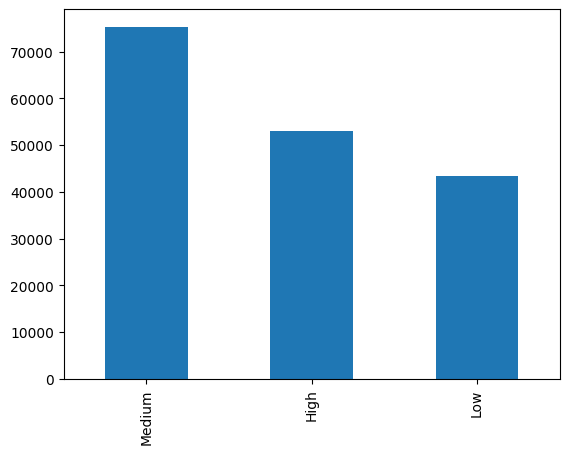

In [14]:
label_counts = y_trust.sum().sort_values(ascending=False).plot(kind='bar')

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [16]:
# Buiding Models Pipeline and Data Spliting
#Stratify on y

X_train, X_test, y_train, y_test = train_test_split(X, y_trust, test_size=.3, random_state=42, stratify=y_trust)

pipeMNB = Pipeline([('tfidg', TfidfVectorizer()), ('clf', OneVsRestClassifier(MultinomialNB()))])
pipeCNB = Pipeline([('tfidg', TfidfVectorizer()), ('clf', OneVsRestClassifier(ComplementNB()))])

In [17]:
X_train = X_train.squeeze()
X_test  = X_test.squeeze()

X_train

,text_cleaned
152835,get st rounder without doubt worth
115459,prisoner moment thats favorite jok pass ever d...
8285,name name ill disagree
62614,accept love think deserve perks wallflower
196227,stay strong
...,...
94024,fully support
149592,go feel body let go
166479,really nice chiaroscuro
59631,nice


In [18]:
# Training and Testing
pipeMNB.fit(X_train, y_train)
predictMNB = pipeMNB.predict(X_test)
scoreMNB = classification_report(y_test, predictMNB)

print(f"Multinomial NB's F1 Score: {f1_score(y_test, predictMNB, average='macro')*100}")
print(scoreMNB)


pipeCNB.fit(X_train, y_train)
predictCNB = pipeCNB.predict(X_test)
scoreCNB = classification_report(y_test, predictCNB)

print(f" Complement NB's F1 Score: {f1_score(y_test, predictCNB, average='macro')*100}")
print(scoreCNB)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Multinomial NB's F1 Score: 38.04515194063222
              precision    recall  f1-score   support

           0       0.79      0.32      0.45     15904
           1       0.64      0.39      0.48     22597
           2       0.65      0.12      0.20     13045

   micro avg       0.68      0.30      0.42     51546
   macro avg       0.69      0.28      0.38     51546
weighted avg       0.69      0.30      0.40     51546
 samples avg       0.30      0.30      0.30     51546

 Complement NB's F1 Score: 57.79090162410879
              precision    recall  f1-score   support

           0       0.59      0.64      0.61     15904
           1       0.60      0.59      0.59     22597
           2       0.47      0.59      0.53     13045

   micro avg       0.56      0.60      0.58     51546
   macro avg       0.55      0.61      0.58     51546
weighted avg       0.57      0.60      0.58     51546
 samples avg       0.53      0.60      0.55     51546



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
print(f" Accuracy MNB: {accuracy_score(y_test, predictMNB)*100}")
print(f" Accuracy CNB: {accuracy_score(y_test, predictCNB)*100}")

 Accuracy MNB: 29.77340627788771
 Accuracy CNB: 45.2527839211578


In [20]:
# Precision
print(f" Precision MNB: {precision_score(y_test, predictMNB, average='macro')*100}")
print(f" Precision CNB: {precision_score(y_test, predictCNB, average='macro')*100}")

 Precision MNB: 69.31742865845405
 Precision CNB: 55.47702368062058


In [14]:
# Recall
print(f" Recall MNB: {recall_score(y_test, predictMNB, average='macro')*100}")
print(f" Recall CNB: {recall_score(y_test, predictCNB, average='macro')*100}")

 Recall MNB: 27.608920430694507
 Recall CNB: 60.61137790714479


In [15]:
# Logistic Regression
pipeLR = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500000,
                              ngram_range=(1,3))),
    ('clf', OneVsRestClassifier(
        LogisticRegression(random_state=42,
            multi_class='multinomial',
            max_iter=2000,
            solver='lbfgs',
            class_weight='balanced',
            n_jobs=-1
        )
    ))
])

In [16]:
pipeLR.fit(X_train, y_train)
predLR = pipeLR.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' w

In [17]:
print(f"Accuracy LR: {accuracy_score(y_test, predLR)*100}")
print("Logistic Regression F1:", f1_score(y_test, predLR, average="macro"))

Accuracy LR: 52.90420207193575
Logistic Regression F1: 0.6275214497008303


In [18]:
print(f" Precision LR: {precision_score(y_test, predLR, average='macro')*100}")
print(f" Recall LR: {recall_score(y_test, predLR, average='macro')*100}")

 Precision LR: 58.30970410976214
 Recall LR: 68.2691067361429


In [19]:
pipeSVM = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500000,
                              min_df=5,
                              max_df=0.9,
                              ngram_range=(1,3),
                              sublinear_tf=True)),
    ('clf', OneVsRestClassifier(
        LinearSVC(random_state=42,
                  C =0.1,
            class_weight='balanced'
        )
    ))
])

In [20]:
pipeSVM.fit(X_train, y_train)
predSVM = pipeSVM.predict(X_test)

In [21]:
print(f"Accuracy SVM: {accuracy_score(y_test, predSVM)*100}")
print("SVM F1:", f1_score(y_test, predSVM, average="macro")*100)

Accuracy SVM: 50.129980987855504
SVM F1: 62.805104608549335


In [22]:
print(f" Precision SVM: {precision_score(y_test, predSVM, average='macro')*100}")
print(f" Recall SVM: {recall_score(y_test, predSVM, average='macro')*100}")

 Precision SVM: 57.63564339083881
 Recall SVM: 69.5397804150306


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [24]:
"""RNN but with num of words = 50000, batch size = 64, epochs = 20, validation split = 0.1
"""

# Tokenize
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len)

# Build RNN
model = Sequential([
    Embedding(input_dim=50000, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(3, activation='sigmoid')  # 28 emotions
])

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train_pad, y_train.values, batch_size=128, epochs=20, validation_split=0.1, callbacks=[es])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.5352 - loss: 0.5696 - val_accuracy: 0.6250 - val_loss: 0.5014
Epoch 2/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.6561 - loss: 0.4699 - val_accuracy: 0.6201 - val_loss: 0.5008
Epoch 3/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.6903 - loss: 0.4287 - val_accuracy: 0.6159 - val_loss: 0.5105
Epoch 4/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7104 - loss: 0.3980 - val_accuracy: 0.6112 - val_loss: 0.5536
Epoch 5/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7226 - loss: 0.3742 - val_accuracy: 0.6073 - val_loss: 0.5897


In [25]:
# Test and Metrics
predRNN_prob = model.predict(X_test_pad)
predRNN = (predRNN_prob > 0.5).astype(int)  # threshold = 0.5


print("RNN F1 :", f1_score(y_test, predRNN, average='macro')*100)
print(classification_report(y_test, predRNN))

1611/1611 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
RNN F1 : 57.93536291254935
              precision    recall  f1-score   support

           0       0.73      0.56      0.63     15904
           1       0.62      0.63      0.62     22597
           2       0.63      0.39      0.48     13045

   micro avg       0.65      0.54      0.59     51546
   macro avg       0.66      0.52      0.58     51546
weighted avg       0.66      0.54      0.59     51546
 samples avg       0.54      0.54      0.54     51546



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


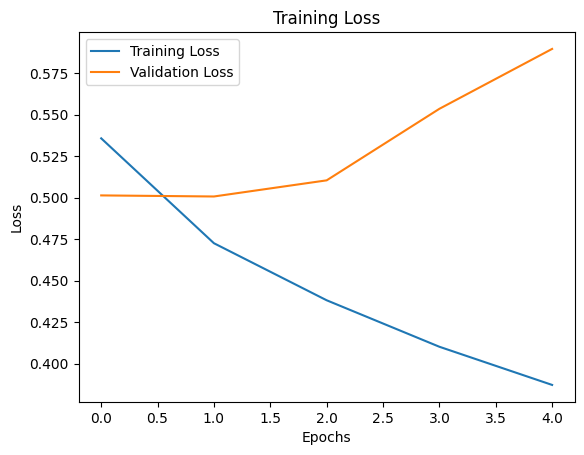

In [26]:
# Plotting Trainig Loss
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training Loss"); plt.show()

In [27]:
"""Improvement for Bidirectional RNN
"""
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

vocab_size_1 = 50000
max_len_1 = 150

tokenizer_1 = Tokenizer(num_words=vocab_size_1)
tokenizer_1.fit_on_texts(X_train)

X_train_seq_1 = tokenizer_1.texts_to_sequences(X_train)
X_test_seq_1  = tokenizer_1.texts_to_sequences(X_test)

X_train_pad_1 = pad_sequences(X_train_seq_1, maxlen=max_len_1, padding='post')
X_test_pad_1  = pad_sequences(X_test_seq_1, maxlen=max_len_1, padding='post')



# Bidirectional LSTM Model

model_1 = Sequential([
    Embedding(input_dim=vocab_size_1, output_dim=128, input_length=max_len_1),

    Bidirectional(LSTM(
        128,
        return_sequences=True,
        dropout=0.2
    )),
    BatchNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(64, dropout=0.2)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(3, activation='softmax')
])


model_1.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [28]:
# Train

rlrop = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

history_1 = model_1.fit(
    X_train_pad_1,
    y_train.values,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    callbacks=[es, rlrop]
)

Epoch 1/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 56s 60ms/step - accuracy: 0.4007 - loss: 1.2442 - val_accuracy: 0.5997 - val_loss: 0.8725 - learning_rate: 0.0010
Epoch 2/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.6305 - loss: 0.8357 - val_accuracy: 0.6186 - val_loss: 0.8709 - learning_rate: 0.0010
Epoch 3/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.6697 - loss: 0.7551 - val_accuracy: 0.6203 - val_loss: 0.8620 - learning_rate: 0.0010
Epoch 4/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.6923 - loss: 0.6987 - val_accuracy: 0.6127 - val_loss: 0.9045 - learning_rate: 0.0010
Epoch 5/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.7055 - loss: 0.6559 - val_accuracy: 0.6104 - val_loss: 0.9394 - learning_rate: 0.0010
Epoch 6/20
846/846 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.7269 - loss: 0.6007 - val_accuracy: 0.6102 - val_loss: 1.0698 - learning_rate: 3.0000e-04


In [29]:
# Predict probabilities
probs_1 = model_1.predict(X_test_pad_1)

# Tune thresholds for each label
best_thresh = []
for i in range(3):
    best_t = 0.5
    best_f1 = 0
    for t in np.arange(0.1, 0.9, 0.02):
        preds_t = (probs_1[:, i] > t).astype(int)
        f1 = f1_score(y_test.iloc[:, i], preds_t)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresh.append(best_t)

best_thresh = np.array(best_thresh)
print(best_thresh)


1611/1611 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step
[0.34 0.3  0.26]


In [30]:
pred_1 = (probs_1 > best_thresh.reshape(1, -1)).astype(int)

print("Bidirectional  F1 :", f1_score(y_test, pred_1, average='macro')*100)
print(classification_report(y_test, pred_1))

Bidirectional  F1 : 62.89790989816826
              precision    recall  f1-score   support

           0       0.62      0.69      0.66     15904
           1       0.55      0.82      0.66     22597
           2       0.49      0.67      0.57     13045

   micro avg       0.56      0.74      0.64     51546
   macro avg       0.56      0.73      0.63     51546
weighted avg       0.56      0.74      0.64     51546
 samples avg       0.60      0.74      0.65     51546



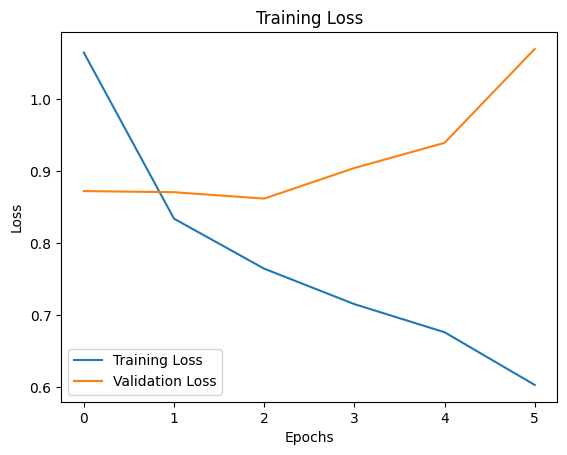

In [31]:
# Plotting Trainig Loss
plt.plot(history_1.history['loss'], label="Training Loss")
plt.plot(history_1.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.title("Training Loss"); plt.show()

In [32]:
import shap
from collections import defaultdict

# classes
three_class_labels = ['High', 'Medium', 'Low']

def shap_top_words_per_label_3class(model, X_data, tokenizer, n_samples=10, top_k=5):
    """
    Compute SHAP values for a 3-class model and extract top words per class.
    """
    # Map token indices back to words
    index_to_word = {v: k for k, v in tokenizer.word_index.items()}

    # Subset for speed
    X_subset = X_data[:n_samples]

    # Wrapper to force inputs to Integer (crucial for Embedding layers)
    def model_predict(x):
        return model.predict(x.astype(int))

    # Initialize SHAP Explainer
    explainer = shap.Explainer(model_predict, X_subset)
    shap_values = explainer(X_subset)

    # Handle Shape Variations (SHAP output format varies by version)
    vals = shap_values.values
    if isinstance(vals, list):
        vals = np.stack(vals, axis=-1)

    # It should now be (n_samples, seq_len, 3)
    num_labels = vals.shape[-1]

    results = {}

    # Iterate over the 3 classes
    for label_idx in range(num_labels):

        word_impact_sum = defaultdict(float)
        word_counts = defaultdict(int)

        for sample_i in range(n_samples):
            for seq_j in range(X_subset.shape[1]):

                token_id = int(X_subset[sample_i, seq_j])

                if token_id == 0: continue # Skip padding

                # Get SHAP value for this specific class (0, 1, or 2)
                shap_val = vals[sample_i, seq_j, label_idx]
                word = index_to_word.get(token_id, "[UNK]")

                # Accumulate
                word_impact_sum[word] += shap_val
                word_counts[word] += 1

        # Calculate average
        avg_word_scores = {}
        for word, total_shap in word_impact_sum.items():
            avg_word_scores[word] = total_shap / word_counts[word]

        # Sort top words for this class
        sorted_words = sorted(avg_word_scores.items(), key=lambda x: x[1], reverse=True)[:top_k]
        results[label_idx] = sorted_words

    return results

#  Run Analysis
shap_results = shap_top_words_per_label_3class(
    model,        #b3-class model
    X_test_pad,   # data
    tokenizer,
    n_samples=20,  Low number for speed
    top_k=5
)

# --- Print Results ---
for idx, words in shap_results.items():
    label_name = three_class_labels[idx] if idx < len(three_class_labels) else f"Class {idx}"
    print(f"\nTop words driving '{label_name}':")
    for word, score in words:
        print(f"  {word}: {score:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━

PermutationExplainer explainer:  20%|██        | 4/20 [00:00<?, ?it/s]

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


PermutationExplainer explainer:  30%|███       | 6/20 [00:13<00:16,  1.19s/it]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


PermutationExplainer explainer: 100%|██████████| 20/20 [00:43<00:00,  2.05s/it]

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


PermutationExplainer explainer: 21it [00:45,  2.69s/it]


Top words driving 'High':
  haha: 0.5272
  lol: 0.4844
  thanks: 0.3846
  great: 0.2816
  romantic: 0.1769

Top words driving 'Medium':
  doubled: 0.1955
  slowing: 0.1457
  tied: 0.1403
  evidence: 0.1369
  bore: 0.1224

Top words driving 'Low':
  disgusting: 0.5666
  foolish: 0.3482
  ridiculous: 0.2785
  weird: 0.2590
  hell: 0.1793


In [33]:
print(f"Accuracy RNN: {accuracy_score(y_test, predRNN)*100}")
print(f"Accuracy BiRNN: {accuracy_score(y_test, pred_1)*100}")

Accuracy RNN: 54.275792496022966
Accuracy BiRNN: 45.08982268265239


In [34]:
print(f"Precision RNN: {precision_score(y_test, predRNN, average='macro')*100}")
print(f"Recall RNN: {recall_score(y_test, predRNN, average='macro')*100}")
print(f"Precision BiRNN: {precision_score(y_test, pred_1, average='macro')*100}")
print(f"Recall BiRNN: {recall_score(y_test, pred_1, average='macro')*100}")

Precision RNN: 66.0954113686516
Recall RNN: 52.421808731487815
Precision BiRNN: 55.69553423882778
Recall BiRNN: 72.88153761381521
